# Relationships on a different dataset: wealth & life expectancy

*Part 1 · Lesson 3 · another dataset  ·  data: Gapminder GDP vs life expectancy, 2007*

*↩ A companion to [Lesson 3: Relationships: correlation & the regression line](03-relationships-regression.ipynb).*

**↩ Back:** [Lesson 3: Relationships: correlation & the regression line](03-relationships-regression.ipynb)  ·  [↑ Course map](../rendered/index.html)  ·  **Also:** [The code behind it →](03-relationships-regression~the-code.ipynb)

In the core lesson we used the **correlation r** and the **least-squares line** on Ames houses, where
bigger area went with higher price along a reasonably **straight** band. Those two tools worked almost
out of the box. This time we'll point the very same tools at a famous question — *do people in richer
countries live longer?* — and discover their **one big blind spot**.

The honest relationship between a country's wealth and its life expectancy is **curved**, not straight.
Because $r$ and the regression line can only see **straight-line** trends, they will quietly *misfit*
the data: the correlation understates how tight the relationship really is, and the line is wrong in a
patterned way you can *read off* a chart. Then we'll apply the single most common fix in all of applied
statistics — a **log transform** — and watch the curve straighten, the correlation jump, and the line
snap into place. Run each grey cell with **Shift+Enter**, then tinker.

> **New to notebooks?** The grey boxes below are **code**. Click one and press **Shift + Enter** to run it — the result (a number, a table, or a chart) appears right underneath. Run them **top to bottom**. You do **not** need to understand the first *"Setup"* cell — it just loads the tools and the data, so run it and move on. And you **can't break anything**: re-running a cell is always safe. *(Brand new to all this? The five-minute [Lesson 0 — How these notebooks work](00-how-these-notebooks-work.ipynb) shows you the basics first.)*

In [1]:
# --- Setup: load our helpers and the data --------------------------------
import sys, pathlib
for _p in [pathlib.Path.cwd(), pathlib.Path.cwd().parent]:
    if (_p / 'lib' / 'statslab.py').exists():
        sys.path.insert(0, str(_p / 'lib')); break
import statslab as sl

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
sl.use_course_style()

GAPMINDER_URL = 'https://raw.githubusercontent.com/kirenz/datasets/master/gapminder.csv'
gap = sl.load_csv('gapminder.csv', url=GAPMINDER_URL)

# Use a single year so each country appears exactly once (a clean cross-section).
g07 = gap[gap['year'] == 2007].copy()

print(f'{len(g07)} countries in 2007')
print(f'GDP per capita ranges from {g07["gdpPercap"].min():,.0f} to {g07["gdpPercap"].max():,.0f} (USD)')
print(f'life expectancy ranges from {g07["lifeExp"].min():.1f} to {g07["lifeExp"].max():.1f} years')
g07[['country', 'continent', 'gdpPercap', 'lifeExp']].head()

142 countries in 2007
GDP per capita ranges from 278 to 49,357 (USD)
life expectancy ranges from 39.6 to 82.6 years


,country,continent,gdpPercap,lifeExp
11,Afghanistan,Asia,974.580338,43.828
23,Albania,Europe,5937.029526,76.423
35,Algeria,Africa,6223.367465,72.301
47,Angola,Africa,4797.231267,42.731
59,Argentina,Americas,12779.379640,75.320


## 1) The first move (always): a scatterplot

Each country gives us **two numbers**: `gdpPercap` (GDP per person, in USD — a rough measure of how
rich the country is) and `lifeExp` (average life expectancy, in years). With two numbers per item, the
picture to draw first is a **scatterplot**: one dot per country, wealth across, lifespan up. Before
computing anything, ask the three questions from the core lesson:

- **Direction** — does life expectancy rise with wealth (positive) or fall (negative)?
- **Form** — is the trend a **straight line**, or **curved**?
- **Strength** — do the dots hug the trend tightly, or scatter widely?

For Ames the form was "roughly a straight line." Watch the **form** here especially carefully.

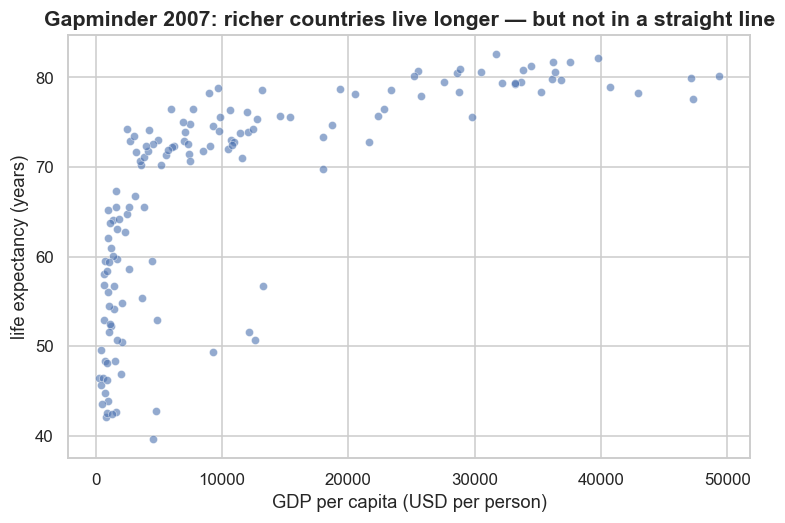

In [2]:
x = g07['gdpPercap'].to_numpy()      # how rich (USD per person)
y = g07['lifeExp'].to_numpy()        # how long (years)

fig, ax = plt.subplots()
ax.scatter(x, y, s=28, alpha=0.6, color='#4c72b0', edgecolor='white', lw=0.4)
ax.set_xlabel('GDP per capita (USD per person)')
ax.set_ylabel('life expectancy (years)')
ax.set_title('Gapminder 2007: richer countries live longer — but not in a straight line')
plt.show()

**Direction:** clearly **up** — richer countries do tend to live longer. **Strength:** fairly strong.
But the **form** is the headline: this is **not** a straight line. It's a **curve** that climbs
*steeply* among the poorest countries and then **flattens** — life expectancy shoots up as a very poor
country gets a little richer, but among already-rich countries, extra wealth buys almost no extra years.
This "rises fast then levels off" shape is called **concave**. Keep it in mind: a straight-line tool is
about to try to summarize a bent reality.

## 2) The correlation r — and why it *understates* a curve

The **correlation $r$** is the average product of the two variables' **z-scores** (each value rewritten
as "how many SDs from its own mean"):

$$r = \frac{1}{n-1}\sum_{i=1}^{n} \left(\frac{x_i-\bar{x}}{s_x}\right)\left(\frac{y_i-\bar{y}}{s_y}\right)$$

It runs from $-1$ to $+1$ and measures the **strength and direction of a *straight-line* trend** — and
that italicized word is the whole point of this lesson. $r$ literally cannot see a curve. A relationship
can be tight and obvious to your eye, yet $r$ reports only how well a **straight** line would do.

In [3]:
r_raw = g07['gdpPercap'].corr(g07['lifeExp'])
print(f'correlation r (GDP per capita, life expectancy) = {r_raw:.3f}')
print('\nThat is a "moderate-to-strong positive" linear trend on the textbook scale.')
print('But your eyes already saw a relationship TIGHTER than 0.68 looks — the curve is the reason.')

correlation r (GDP per capita, life expectancy) = 0.679

That is a "moderate-to-strong positive" linear trend on the textbook scale.
But your eyes already saw a relationship TIGHTER than 0.68 looks — the curve is the reason.


$r \approx 0.68$ sounds only moderately strong — yet the scatterplot looked tighter than that. The gap
between "what my eyes see" and "what $r$ says" is the **fingerprint of a curve**. Because $r$ scores
the data against a *straight* line, and the truth bends away from any straight line, $r$ gets *penalized*
for the curvature and **understates** the real association.

> **The core lesson's warning, now live:** *"a small $r$ means no **linear** trend, not no
> relationship."* Here $r$ isn't small, but it's **smaller than the truth deserves** — same blind spot,
> milder symptom. Always look at the scatter before trusting a single number.

## 3) Fit the least-squares line anyway — and let it betray itself

Let's fit the straight line the formulas give us, exactly as we did for Ames:

$$\hat{y} = b_0 + b_1 x, \qquad b_1 = r\,\frac{s_y}{s_x}, \qquad b_0 = \bar{y} - b_1\bar{x}.$$

The math will dutifully hand back *a* line — the best straight line possible. The question is whether
the best *straight* line is any good when the truth is *curved*.

slope b1     = 0.00064 years per extra USD of GDP/person
intercept b0 = 59.57 years
R^2 = r^2    = 0.461   (the line explains ~46% of the variation)


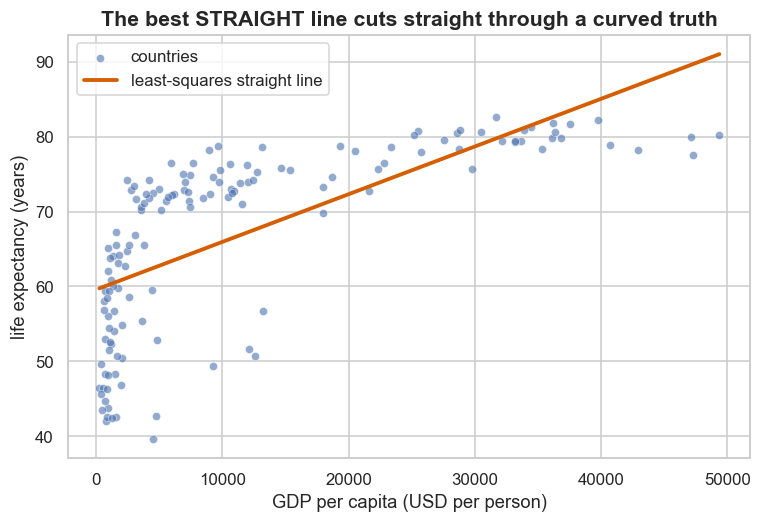

In [4]:
fit_raw = stats.linregress(x, y)
b1, b0 = fit_raw.slope, fit_raw.intercept
print(f'slope b1     = {b1:.5f} years per extra USD of GDP/person')
print(f'intercept b0 = {b0:.2f} years')
print(f'R^2 = r^2    = {fit_raw.rvalue**2:.3f}   (the line explains ~{fit_raw.rvalue**2*100:.0f}% of the variation)')

line_x = np.linspace(x.min(), x.max(), 200)
line_y = b0 + b1 * line_x

fig, ax = plt.subplots()
ax.scatter(x, y, s=28, alpha=0.6, color='#4c72b0', edgecolor='white', lw=0.4, label='countries')
ax.plot(line_x, line_y, color='#D55E00', lw=2.5, label='least-squares straight line')
ax.set_xlabel('GDP per capita (USD per person)')
ax.set_ylabel('life expectancy (years)')
ax.set_title('The best STRAIGHT line cuts straight through a curved truth')
ax.legend(); plt.show()

Look at *how* the line misses. It runs **above** the dots among the poorest countries (it predicts they
live longer than they do), **below** the dots in the middle (it predicts they live shorter than they
do), and **above** the dots again at the rich end. The line and the cloud cross like an X. That's not
random sloppiness — it's a **systematic, patterned** miss, the unmistakable signature of fitting a
straight line to a curve. The slope is also nearly impossible to interpret usefully: "0.0006 extra years
per extra USD" averages a steep effect among the poor with almost no effect among the rich into one
number that describes **neither** group.

## 4) Residuals — the diagnostic that *names* the problem

A single picture can hide a misfit; the **residual plot** exposes it. The **residual** for each country
is what the line missed:

$$e_i = y_i - \hat{y}_i = (\text{actual lifespan}) - (\text{predicted lifespan}).$$

A **residual plot** puts the predicted value on $x$ and the residual on $y$. What you *want* — what
"this straight line is the right model" looks like — is a **shapeless, horizontal band around 0**: only
random scatter left over. A **curve** in the residual plot is the diagnosis of **nonlinearity**: it says
the straight line left behind a *pattern* it failed to capture.

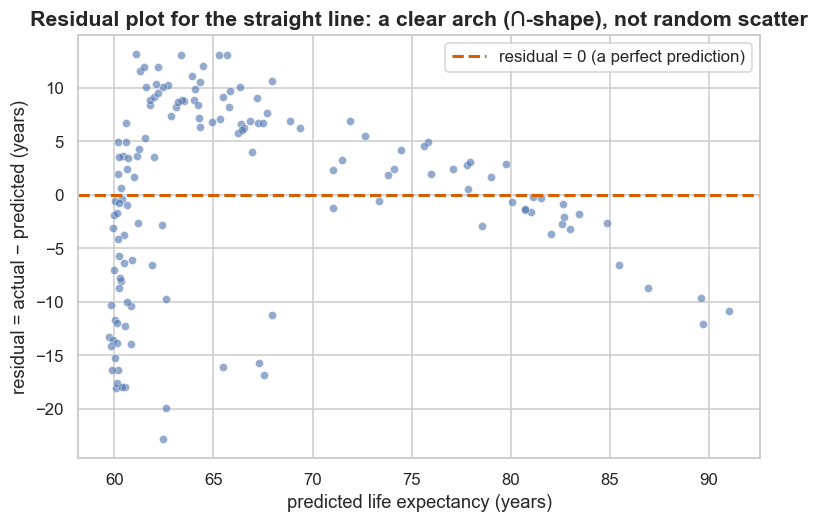

Residuals still average to ~0: mean = 0.000 years
...but they are NOT shapeless. They rise into positive then fall back — an arch (∩).
That leftover curve is the straight line confessing it is the wrong shape.


In [5]:
predicted_raw = b0 + b1 * x
residuals_raw = y - predicted_raw

fig, ax = plt.subplots()
ax.scatter(predicted_raw, residuals_raw, s=28, alpha=0.6, color='#4c72b0', edgecolor='white', lw=0.4)
ax.axhline(0, color='#D55E00', lw=2, ls='--', label='residual = 0 (a perfect prediction)')
ax.set_xlabel('predicted life expectancy (years)')
ax.set_ylabel('residual = actual − predicted (years)')
ax.set_title('Residual plot for the straight line: a clear arch (∩-shape), not random scatter')
ax.legend(); plt.show()

print(f'Residuals still average to ~0: mean = {residuals_raw.mean():.3f} years')
print('...but they are NOT shapeless. They rise into positive then fall back — an arch (∩).')
print('That leftover curve is the straight line confessing it is the wrong shape.')

There it is: the residuals trace a clear **arch (∩ shape)** instead of a flat band. The line
**over**-predicts at both ends (so the residuals dip negative there) and **under**-predicts in the middle
(where they bulge positive) — negative, then positive, then negative again. This is exactly what
the core lesson told you to dread — *"a curve or a funnel is a warning that a straight line is the wrong
model."* On Ames the residual band was basically flat (it only fanned a little at the high end); here it
**bends**, and that bend is the whole story.

**How to read a residual plot, in one line:** *flat shapeless band → the line fits; a curve → you fit
the wrong shape; a funnel (fanning) → the spread isn't constant.* A residual plot turns "my line looks
off" into a specific, named diagnosis.

## 5) The fix: a log transform straightens the curve

So the relationship is real but **bent** — what now? We don't abandon the line; we **change the ruler**
we measure wealth on. The standard fix for a predictor that is **right-skewed** and acts
**multiplicatively** is to take its **logarithm**.

Why a log? Two reasons that are really one:

- **GDP is hugely right-skewed.** Most countries are clustered at low income with a long tail of rich
  ones, so the x-axis is stretched: the gap from 500 to 5,000 USD (a *tenfold* jump in living standards)
  is squashed into the same little sliver as the gap from 40,000 to 44,500. A log axis makes **equal
  ratios** (×10) take **equal space**, un-squashing the poor countries where all the action is.
- **The effect of wealth is multiplicative.** What seems to matter for lifespan isn't *adding* a fixed
  number of dollars, it's *multiplying* income — doubling a poor country's GDP helps far more than adding
  the same dollars to a rich one. `log10(gdp)` measures wealth in "powers of ten," which is exactly the
  scale on which the effect is roughly constant — i.e. **straight**.

Let's confirm the skew is the culprit, then look at wealth on a log scale.

skew of gdpPercap        = +1.21   <- strongly RIGHT-skewed (long rich tail)
skew of log10(gdpPercap) = -0.15   <- nearly symmetric: the log tamed it


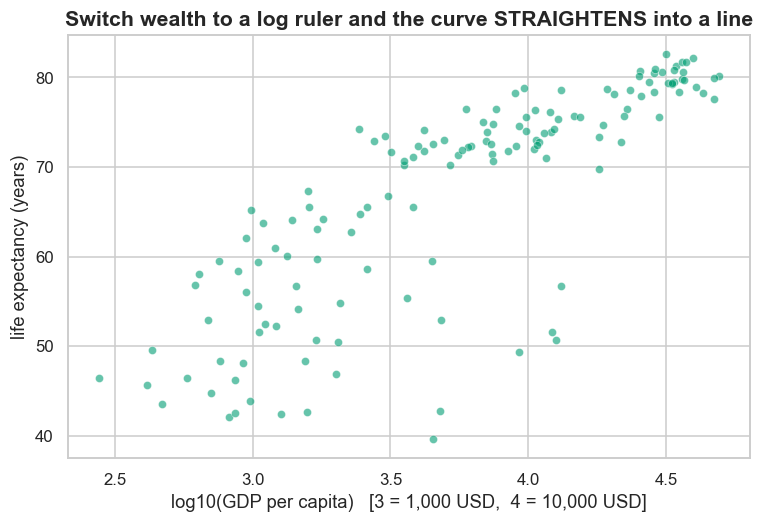

In [6]:
skew_raw = stats.skew(g07['gdpPercap'])
log_gdp  = np.log10(g07['gdpPercap'])
skew_log = stats.skew(log_gdp)

print(f'skew of gdpPercap        = {skew_raw:+.2f}   <- strongly RIGHT-skewed (long rich tail)')
print(f'skew of log10(gdpPercap) = {skew_log:+.2f}   <- nearly symmetric: the log tamed it')

# Same data, same y, but wealth now on a log10 ruler.
gl = np.log10(x)
fig, ax = plt.subplots()
ax.scatter(gl, y, s=28, alpha=0.6, color='#009E73', edgecolor='white', lw=0.4)
ax.set_xlabel('log10(GDP per capita)   [3 = 1,000 USD,  4 = 10,000 USD]')
ax.set_ylabel('life expectancy (years)')
ax.set_title('Switch wealth to a log ruler and the curve STRAIGHTENS into a line')
plt.show()

The bend is gone. On the log ruler the dots fall along a believable **straight band** — equal *ratios*
of wealth now buy roughly equal extra years, which is what a straight line needs. (Reading the axis:
`3` means $10^3 = 1{,}000$ USD, `4` means $10^4 = 10{,}000$ USD — each step right is a *tenfold* richer
country.) Now re-run the same two tools, $r$ and the least-squares line, on the transformed predictor.

correlation r:      raw = 0.679   ->   log = 0.809    (jumped up!)
R^2 = r^2:          raw = 0.461   ->   log = 0.654

log-line slope b1 = 16.59 years per 10x increase in GDP per capita
log-line intercept b0 = 4.95 years


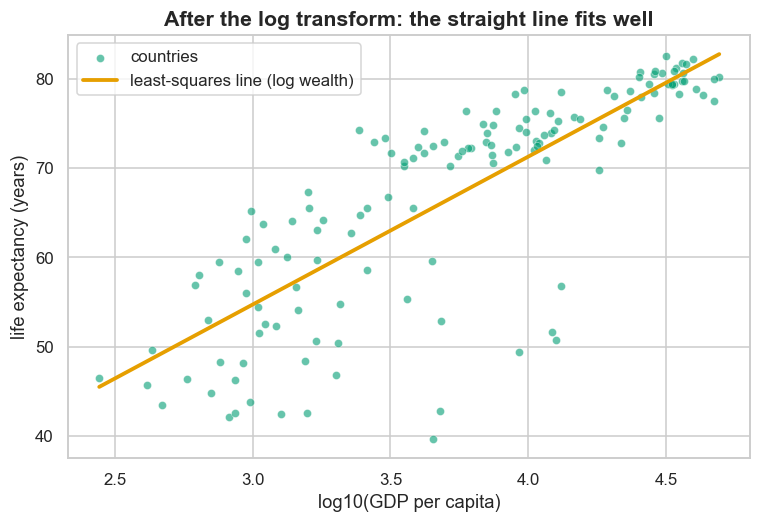

In [7]:
r_log = log_gdp.corr(g07['lifeExp'])
fit_log = stats.linregress(gl, y)
b1L, b0L = fit_log.slope, fit_log.intercept

print(f'correlation r:      raw = {r_raw:.3f}   ->   log = {r_log:.3f}    (jumped up!)')
print(f'R^2 = r^2:          raw = {r_raw**2:.3f}   ->   log = {r_log**2:.3f}')
print(f'\nlog-line slope b1 = {b1L:.2f} years per 10x increase in GDP per capita')
print(f'log-line intercept b0 = {b0L:.2f} years')

logline_x = np.linspace(gl.min(), gl.max(), 200)
logline_y = b0L + b1L * logline_x

fig, ax = plt.subplots()
ax.scatter(gl, y, s=28, alpha=0.6, color='#009E73', edgecolor='white', lw=0.4, label='countries')
ax.plot(logline_x, logline_y, color='#E69F00', lw=2.5, label='least-squares line (log wealth)')
ax.set_xlabel('log10(GDP per capita)')
ax.set_ylabel('life expectancy (years)')
ax.set_title('After the log transform: the straight line fits well')
ax.legend(); plt.show()

The correlation climbs from $r \approx 0.68$ to $r \approx 0.81$, and $R^2$ from about 0.46 to 0.65 —
the **same data**, but now the straight-line tool is finally matched to a straight-line truth, so it
captures much more of the variation. **Nothing about the countries changed**; we only changed the ruler
we measured wealth on. The slope is now interpretable too: about **17 more years of life for every
tenfold increase** in GDP per person.

Now the real test — does the **residual plot** agree the fix worked?

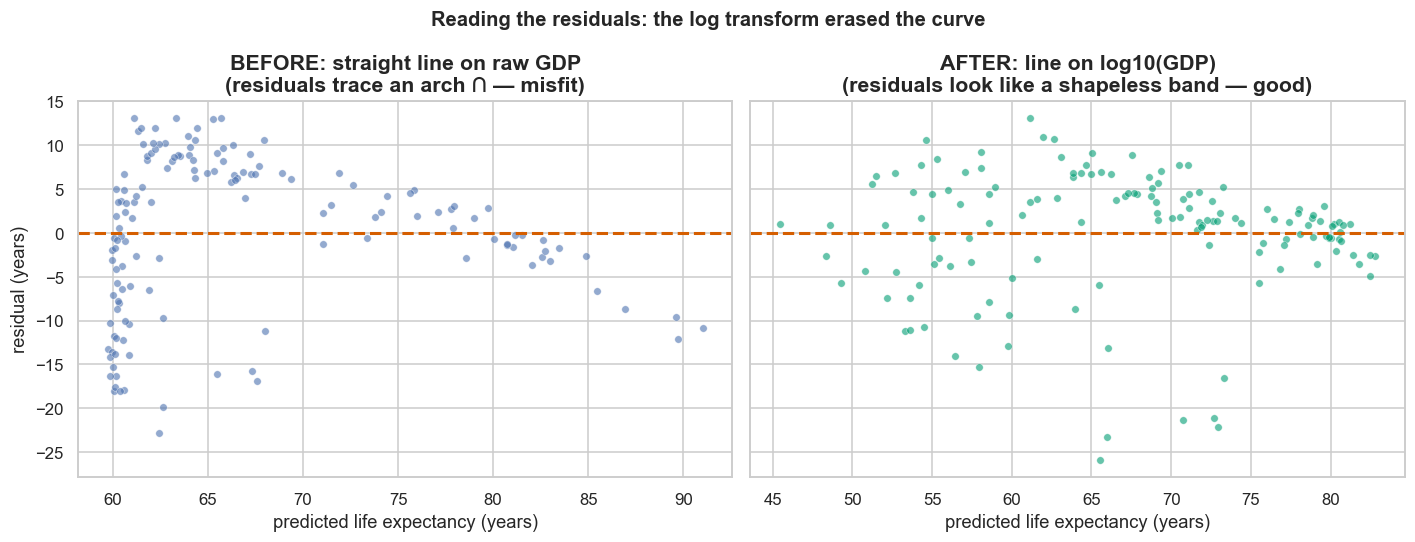

Left: a patterned arch (∩) — the model is the wrong shape.
Right: scatter with no obvious trend — the straight line now fits the data.


In [8]:
predicted_log = b0L + b1L * gl
residuals_log = y - predicted_log

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 5.0), sharey=True)

axL.scatter(predicted_raw, residuals_raw, s=24, alpha=0.6, color='#4c72b0', edgecolor='white', lw=0.4)
axL.axhline(0, color='#D55E00', lw=2, ls='--')
axL.set_title('BEFORE: straight line on raw GDP\n(residuals trace an arch ∩ — misfit)')
axL.set_xlabel('predicted life expectancy (years)')
axL.set_ylabel('residual (years)')

axR.scatter(predicted_log, residuals_log, s=24, alpha=0.6, color='#009E73', edgecolor='white', lw=0.4)
axR.axhline(0, color='#D55E00', lw=2, ls='--')
axR.set_title('AFTER: line on log10(GDP)\n(residuals look like a shapeless band — good)')
axR.set_xlabel('predicted life expectancy (years)')

fig.suptitle('Reading the residuals: the log transform erased the curve', fontweight='bold')
plt.tight_layout(); plt.show()

print('Left: a patterned arch (∩) — the model is the wrong shape.')
print('Right: scatter with no obvious trend — the straight line now fits the data.')

Side by side, the diagnosis and the cure are obvious. The **before** residuals bend in an **arch (∩)**;
the **after** residuals are a shapeless cloud hovering around 0 — the very thing the core lesson said to
*want*. That flat band is your evidence that the straight line, **on log wealth**, is now the right
model. This is the everyday workflow of a working analyst: *fit, look at the residuals, and if they
show a pattern, transform and refit.*

## 6) The contrast with Ames — and why r and the line have a blind spot

Step back and compare the two relationships, because the difference *is* the lesson:

| | **Ames** (core lesson) | **Gapminder** (this lesson) |
|---|---|---|
| Honest form of the relationship | roughly **straight** | clearly **curved** (concave) |
| Did the raw straight line fit? | **yes**, fairly directly | **no** — systematic, patterned miss |
| Residual plot of the raw fit | roughly flat (slight fanning) | a clear **arch (∩ curve)** |
| What $r$ reported | a fair summary ($\approx 0.71$) | an **understatement** ($\approx 0.68$) |
| Fix needed | none | **log-transform** wealth ($r \to 0.81$) |

The common thread: **the correlation $r$ and the least-squares line are LINEAR tools.** They answer one
question — *"how well does a straight line describe this?"* On Ames that question matched reality, so the
tools worked out of the box. On Gapminder the honest relationship is curved, so the tools misfit — until
a log transform reshapes the data into something straight. The tools never "fail"; they faithfully
report the best **straight-line** answer. It's our job to **check the form first** (scatter + residuals)
and reshape the data when a straight line is the wrong question.

## 7) And still: correlation is not causation

Even with a beautiful straight fit on log wealth, we must repeat the core lesson's hardest rule. A high
$r$ — even $0.81$ — does **not** prove that getting richer *causes* people to live longer. Wealth and
longevity are tangled up with a web of **shared causes**: richer countries tend to have better
**health systems**, cleaner **water and sanitation**, more **education**, more **vaccination**, safer
food. Those forces push *both* GDP and life expectancy up together, which is enough to manufacture a
strong correlation **without** wealth itself being the direct cause.

A variable like "quality of public health" that drives both is a **confounder** (a lurking variable) —
exactly the role hot weather played in the ice-cream-and-drownings story of the core lesson. To earn the
word *"causes"* you'd need a controlled comparison or careful adjustment for these confounders, not just
a tight scatterplot. Until then, the honest phrasing stays: wealth is **strongly associated with**
longer life — not proven to **cause** it.

## Now you try

Predict what will happen *before* you run each change:

1. **Try a natural log instead of log10.** In section 5, replace `np.log10(g07['gdpPercap'])` with
   `np.log(g07['gdpPercap'])` in a new cell and recompute the correlation. Predict first: does the
   *correlation* change? (It shouldn't — any log base is the same rescaling, and $r$ is unitless. Only
   the slope's units change.)

2. **A half-fix: square root.** A milder transform is the square root. In a new cell compute
   `rs = np.sqrt(g07['gdpPercap'])`, then its correlation with `lifeExp` and its residual plot. Is
   $r$ between the raw 0.68 and the log 0.81? Does the residual arch (∩) shrink but not fully vanish? (A square
   root straightens *less* aggressively than a log.)

3. **Don't transform — split instead.** Keep raw GDP, but fit the straight line only to the **poorest
   half** of countries (`g07[g07['gdpPercap'] < g07['gdpPercap'].median()]`). Within just the poor
   countries the curve is closer to straight — is the raw-GDP fit there better than across all 142?

4. **Pick a different year.** Change `g07 = gap[gap['year'] == 2007]` to `1952` or `1977`. Is the
   wealth-vs-lifespan relationship still curved? Does the log transform still help? (Tip: `gap['year']
   .unique()` lists the available years.)

## What you learned

- The **scatterplot comes first**: read **direction, form, and strength**. Here the **form** was the
  whole story — a **curved** (concave) rise that flattens, not the near-straight Ames band.
- The **correlation $r$** and the **least-squares line** are **linear** tools: they score only how well
  a *straight* line fits. Against a curve, $r$ **understates** the relationship (0.68 here) and the line
  misfits in a **patterned** way.
- A **residual plot** is the diagnostic: a **flat shapeless band** means the line fits; a **curve** (the
  arch ∩ we saw) diagnoses **nonlinearity** — the wrong-shape model. This is how you *read* a misfit.
- A **log transform** is the standard fix for a **right-skewed, multiplicative** predictor: it tamed
  GDP's skew (from $+1.2$ to about $0$), straightened the cloud, lifted $r$ from $\approx 0.68$ to
  $\approx 0.81$, and turned the arch-shaped (∩) residuals into random scatter.
- **The contrast with Ames:** same two tools, opposite outcomes — they worked directly on a straight
  relationship and misfit a curved one until the data was reshaped. *Check the form, then choose the
  tool.*
- **Correlation is still not causation:** even a tight log-linear fit doesn't prove wealth *causes*
  longevity — shared **confounders** (health systems, education, sanitation) drive both. Say
  **"associated with."**

---

**↩ Back to the lesson:** [Lesson 3: Relationships: correlation & the regression line](03-relationships-regression.ipynb)  ·  [↑ Course map](../rendered/index.html)  ·  **Also:** [The code behind it](03-relationships-regression~the-code.ipynb)